# Week 6, Day 1: AFL Data Foundations

**EDA, Feature Engineering, and Prediction Targets**

Goal: understand the raw AFL data deeply enough to support two end products this week, a domain locked chat assistant and a prediction system (match winners, top players, goal kickers). This notebook covers Tasks 1 through 5. No modeling happens today, this is the foundation the rest of the week's models and the agent will rely on.

Place all four CSV files in the same folder as this notebook before running:
- `afl_players_info_raw.csv`
- `afl_players_seasonal_stats_raw.csv`
- `afl_players_round_by_round_stats_raw.csv`
- `team_matches_home_away_raw.csv`

The fourth file was added after the first pass of this notebook. It carries home/away, venue, crowd, and actual team scores, resolving two of the structural gaps flagged below. Player position and weather are still not available in any of the four files.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (9, 5)

info = pd.read_csv('../afl_players_info_raw.csv')
season = pd.read_csv('../afl_players_seasonal_stats_raw.csv', low_memory=False)
rbr = pd.read_csv('../afl_players_round_by_round_stats_raw.csv', low_memory=False)
ha = pd.read_csv('../team_matches_home_away_raw.csv', low_memory=False)

print('info:', info.shape)
print('season:', season.shape)
print('round_by_round:', rbr.shape)
print('team_matches_home_away:', ha.shape)


info: (2848, 16)
season: (25491, 54)
round_by_round: (274089, 36)
team_matches_home_away: (15808, 19)


## Task 1: Data Inventory and Understanding

### What each table is, and its grain

| Table | Grain (what one row is) | Key columns |
|---|---|---|
| `afl_players_info_raw` | one row per player, career level | `id`, name fields, `born_date`, `debut_date`, `last_date`, `height`, `weight`, `player_teams` |
| `afl_players_seasonal_stats_raw` | one row per player per season (split further by `is_finals` True/False) | `player_id`, `year`, `team`, `is_finals`, totals and per game averages |
| `afl_players_round_by_round_stats_raw` | one row per player per match (player game grain) | `player_id`, `team`, `opponent`, `year`, `round`, `match_date`, per game stat columns, `result`, `margin`, `fantasy_points` |
| `team_matches_home_away_raw` | one row per team per match (team game grain, two rows per match) | `team_name`, `opponent`, `match_date`, `home_away`, `venue`, `crowd`, `team_score`, `opponent_score`, `result`, `margin` |

### How the tables join

- `afl_players_info_raw.id` = `afl_players_round_by_round_stats_raw.player_id` = `afl_players_seasonal_stats_raw.player_id`.
- `team_matches_home_away_raw` joins to `afl_players_round_by_round_stats_raw` on `match_date` + `team` + `opponent`, after cleaning team name whitespace and casing (see data quality below). Every one of the 14,700 team-match combinations in the round-by-round file has an exact match in the home/away file, and the home/away file additionally covers 1,108 team-match rows that don't appear in round-by-round, likely matches with no tracked player rows in that source.
- There is no shared match id across files, matches are reconstructed by grouping on date and team pair.

### Structural gaps

1. **No player position field**, still true across all four files. Forward/midfielder/defender splits are still not derivable without an external mapping. Not guessing this.
2. **No weather data**, still true across all four files.
3. **Team name changes over time**, confirmed below (Fitzroy Lions folded into the Brisbane Bears in 1996 to form the Brisbane Lions from 1997). Stable otherwise.
4. **Player roster coverage ramps up over time** in the round-by-round file, confirmed below: early seasons only have 1 to 2 tracked players per team per match, full ~22 man rosters aren't reliable until around 1999. Team-level facts sourced from `team_matches_home_away_raw` (`result`, `margin`, `team_score`, venue, crowd) don't have this problem, they're complete across all years. Only features built by aggregating individual player rows are restricted to 1999 onward.
5. **New from the home/away file: whitespace, tabs, and inconsistent casing in team names.** `team_name` and `opponent` contain leading/trailing tabs and spaces (e.g. `'\tRichmond Tigers'`), an inconsistent abbreviation (`'W. Bulldogs'` instead of `'Western Bulldogs'`), and about 15% of `opponent` values are all lowercase. `venue` has the same trailing-whitespace issue. All of this is cleaned below before joining or aggregating.
6. **`afl_players_info_raw` has 5 exact duplicate `id` rows**, and 257 `player_name` values have stray leading/trailing whitespace (e.g. `' Jeremy Cameron'`). Both fixed below before this table is used to attach names to any player_id.
7. **266 `player_id` values appear in `round_by_round` with no matching row in the info table at all** (about 1% of reliable-era rows). These players can't be named, they're labeled explicitly as `[unknown id ...]` rather than silently dropped or left blank.


In [55]:
# duplicate check, round-by-round
dupe_count = rbr['id'].duplicated().sum()
print('Exact duplicate row ids in round_by_round:', dupe_count)
rbr = rbr.drop_duplicates(subset=['id'], keep='first').copy()
rbr['match_date'] = pd.to_datetime(rbr['match_date'])

print('Seasons covered (round_by_round):', rbr['year'].min(), 'to', rbr['year'].max())
print('Teams:', rbr['team'].nunique())
print('Players in round_by_round:', rbr['player_id'].nunique())
print('Players in info table:', info['id'].nunique())
print('Exact duplicate ids in home/away file:', ha['id'].duplicated().sum())


Exact duplicate row ids in round_by_round: 10
Seasons covered (round_by_round): 1983 to 2025
Teams: 20
Players in round_by_round: 3109
Players in info table: 2843
Exact duplicate ids in home/away file: 0


In [56]:
# data quality in the home/away file: whitespace, tabs, casing, abbreviations
print('Raw team_name values with tabs or stray spaces (sample):')
print([t for t in ha['team_name'].unique() if t.strip() != t or '\t' in t][:5])

print('\nLowercase opponent rows:', ha['opponent'].str.islower().sum(), '/', len(ha))
print('Abbreviated team name found:', ha['team_name'].str.contains('W. Bulldogs').sum(), 'rows')

def clean_team(s):
    return s.strip().replace('\t', '').strip()

ha['team'] = ha['team_name'].apply(clean_team).replace({'W. Bulldogs': 'Western Bulldogs'})
ha['opponent'] = ha['opponent'].apply(clean_team).replace({'W. Bulldogs': 'Western Bulldogs'}).str.title()
ha['venue'] = ha['venue'].str.strip()
ha['match_date'] = pd.to_datetime(ha['match_date'])

rbr_teams = set(rbr['team'].unique())
ha_teams = set(ha['team'].unique())
print('\nTeam names after cleaning, still mismatched vs round_by_round:', ha_teams - rbr_teams)


Raw team_name values with tabs or stray spaces (sample):
['\tSt Kilda Saints', '\tW. Bulldogs', '\tBrisbane Lions', '\tCarlton Blues', '\tEssendon Bombers']

Lowercase opponent rows: 2345 / 15808
Abbreviated team name found: 982 rows

Team names after cleaning, still mismatched vs round_by_round: set()


In [57]:
# confirm result/margin are consistent across all players on the same side of a match (round_by_round)
consistency_check = rbr.groupby(['team','opponent','match_date'])[['result','margin']].nunique()
print('Matches where result varies within one team-side:', (consistency_check['result'] > 1).sum())
print('Matches where margin varies within one team-side:', (consistency_check['margin'] > 1).sum())

# join coverage check: every round_by_round team-match should exist in the cleaned home/away file
rbr_keys = set(zip(rbr['match_date'], rbr['team'], rbr['opponent']))
ha_keys = set(zip(ha['match_date'], ha['team'], ha['opponent']))
print('\nround_by_round team-matches missing from home/away file:', len(rbr_keys - ha_keys))
print('home/away team-matches not present in round_by_round:', len(ha_keys - rbr_keys))


Matches where result varies within one team-side: 0
Matches where margin varies within one team-side: 0

round_by_round team-matches missing from home/away file: 0
home/away team-matches not present in round_by_round: 1108


In [58]:
# structural change: Fitzroy Lions -> Brisbane Lions merger
print('Fitzroy Lions active years:', sorted(rbr[rbr['team']=='Fitzroy Lions']['year'].unique()))
print('Brisbane Bears active years:', sorted(rbr[rbr['team']=='Brisbane Bears']['year'].unique()))
print('Brisbane Lions first years:', sorted(rbr[rbr['team']=='Brisbane Lions']['year'].unique())[:3])


Fitzroy Lions active years: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996)]
Brisbane Bears active years: [np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996)]
Brisbane Lions first years: [np.int64(1997), np.int64(1998), np.int64(1999)]


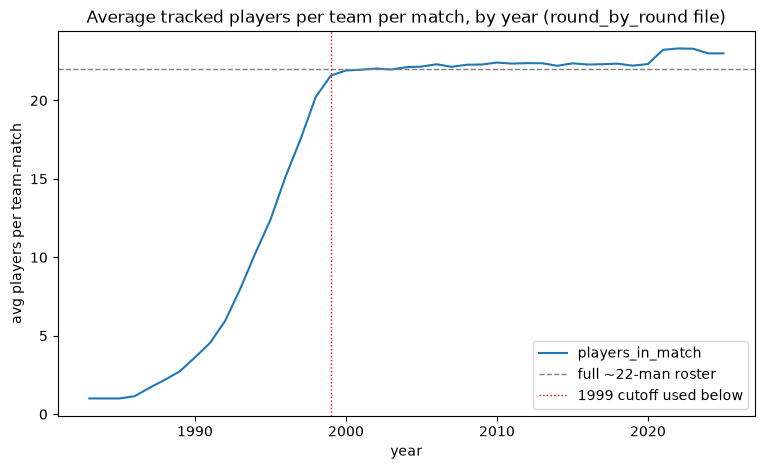


From 1999 onward, avg players per match: 22.4


In [59]:
# roster coverage ramp-up: average distinct players per team per match, by year (round_by_round only)
coverage = (rbr.groupby(['match_date','team'])['player_id'].nunique()
            .reset_index()
            .rename(columns={'player_id': 'players_in_match'}))
coverage['year'] = coverage['match_date'].dt.year
coverage_by_year = coverage.groupby('year')['players_in_match'].mean()
coverage_by_year.plot(title='Average tracked players per team per match, by year (round_by_round file)')
plt.axhline(22, color='gray', linestyle='--', linewidth=1, label='full ~22-man roster')
plt.axvline(1999, color='red', linestyle=':', linewidth=1, label='1999 cutoff used below')
plt.ylabel('avg players per team-match')
plt.legend()
plt.show()

RELIABLE_FROM = 1999
print('\nFrom', RELIABLE_FROM, 'onward, avg players per match:',
      round(coverage_by_year[coverage_by_year.index >= RELIABLE_FROM].mean(), 1))


In [60]:
# missingness, both files
print('Round-by-round missing % (top 10):')
print((rbr.isna().mean() * 100).sort_values(ascending=False).head(10))
print('\nHome/away file missing % (top 5):')
print((ha.isna().mean() * 100).sort_values(ascending=False).head(5))


Round-by-round missing % (top 10):
score                        100.000000
brownlow_votes                40.306262
goal_assist                   37.795672
bounces                       35.512754
hit_outs                      35.252245
marks_inside_50               33.336374
contested_marks               33.080973
behinds                       29.583806
goals                         27.264767
percentage_of_game_played     25.420773
dtype: float64

Home/away file missing % (top 5):
crowd         2.517713
id            0.000000
round         0.000000
team_name     0.000000
match_date    0.000000
dtype: float64


### Outliers in key stats

Missingness and duplicates are covered above; this section checks the *values* themselves. The goal
isn't to remove big performances (a 40-disposal game is real AFL, not an error), it's to separate two
different things that can both show up as an extreme number:

- **Legitimate extreme performances** — genuinely huge games that should stay in the data untouched.
- **Data entry / parsing errors** — e.g. a stat that's off by a factor of 10, a negative count, or a
  value that's structurally impossible (more goals than scoring shots, disposals below 0).

Flagging is done with a *wide* IQR fence (Q1/Q3 ± 3×IQR, not the usual 1.5×) specifically so normal
big-game variance doesn't get caught — only genuinely extreme values get flagged for manual look.
Every flagged row is then checked against known AFL records rather than assumed to be an error.

In [61]:
# Outlier check 1: distributional summary + wide-fence flagging for key per-game stats
# Reliable era only (1999+), so a 2-tracked-player early-era game doesn't distort the ranges
rbr_reliable_check = rbr[rbr['year'] >= RELIABLE_FROM].copy()

key_stats = ['disposals', 'goals', 'marks', 'tackles', 'kicks', 'handballs', 'fantasy_points']
print(rbr_reliable_check[key_stats].describe().round(1))

print('\nWide-fence (Q1-3*IQR to Q3+3*IQR) outlier flags, reliable era:')
for col in key_stats:
    s = rbr_reliable_check[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 3 * iqr, q3 + 3 * iqr
    flagged = s[(s < low) | (s > high)]
    print(f'{col:>15}: fence [{low:6.1f}, {high:6.1f}]  |  {len(flagged):5d} rows flagged '
          f'({len(flagged) / len(s):.2%})  |  min {s.min():.0f}  |  max {s.max():.0f}')

print('\nStructurally impossible values (should all be zero if the source data is clean):')
print('negative disposals:', (rbr_reliable_check['disposals'] < 0).sum())
print('negative goals:', (rbr_reliable_check['goals'] < 0).sum())
if {'goals', 'behinds'}.issubset(rbr_reliable_check.columns):
    print('goals+behinds below 0:', ((rbr_reliable_check['goals'] + rbr_reliable_check['behinds']) < 0).sum())


       disposals     goals     marks   tackles     kicks  handballs  \
count   230071.0  185141.0  232293.0  219960.0  236323.0   234406.0   
mean        15.2       0.7       4.1       2.7       9.1        6.5   
std          7.3       1.1       2.6       2.1       4.7        4.1   
min         -5.0       0.0       0.0       0.0       0.0        0.0   
25%         10.0       0.0       2.0       1.0       6.0        3.0   
50%         14.0       0.0       4.0       2.0       9.0        6.0   
75%         20.0       1.0       6.0       4.0      12.0        9.0   
max         54.0      14.0      24.0      20.0      37.0       35.0   

       fantasy_points  
count        237193.0  
mean             66.2  
std              28.0  
min              -8.0  
25%              47.0  
50%              65.0  
75%              85.0  
max             204.0  

Wide-fence (Q1-3*IQR to Q3+3*IQR) outlier flags, reliable era:
      disposals: fence [ -20.0,   50.0]  |      5 rows flagged (0.00%)  |  min -

In [62]:
# Outlier check 2: look at the actual rows behind the top flagged values, not just the count.
# This is the step that turns "N rows flagged" into "here's whether that's a real record or a bug".
top_disposals = rbr_reliable_check.nlargest(5, 'disposals')[
    ['player_id', 'team', 'opponent', 'match_date', 'disposals']]
top_goals = rbr_reliable_check.nlargest(5, 'goals')[
    ['player_id', 'team', 'opponent', 'match_date', 'goals']]
top_fantasy = rbr_reliable_check.nlargest(5, 'fantasy_points')[
    ['player_id', 'team', 'opponent', 'match_date', 'fantasy_points']]

print('Top 5 single-game disposal counts (sanity check vs. known AFL records, ~50s range):')
print(top_disposals)
print('\nTop 5 single-game goal counts (sanity check vs. known AFL records, single digits to low teens per game):')
print(top_goals)
print('\nTop 5 single-game fantasy_points totals:')
print(top_fantasy)


Top 5 single-game disposal counts (sanity check vs. known AFL records, ~50s range):
        player_id                       team             opponent match_date  \
167386      44910  North Melbourne Kangaroos      Richmond Tigers 2025-08-17   
213046      44510             Hawthorn Hawks  Collingwood Magpies 2018-03-24   
269304      43262            Gold Coast Suns  Collingwood Magpies 2012-06-03   
165386      44585             Brisbane Lions      Richmond Tigers 2019-08-25   
270187      45089             Adelaide Crows      Gold Coast Suns 2011-08-20   

        disposals  
167386       54.0  
213046       54.0  
269304       53.0  
165386       51.0  
270187       51.0  

Top 5 single-game goal counts (sanity check vs. known AFL records, single digits to low teens per game):
        player_id               team                       opponent  \
183270      45460  West Coast Eagles                 Adelaide Crows   
129212      43847     Hawthorn Hawks      North Melbourne Kangaroos

C:\Users\drsho\AppData\Local\Temp\ipykernel_2376\617093484.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, whis=3, vert=True)
C:\Users\drsho\AppData\Local\Temp\ipykernel_2376\617093484.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, whis=3, vert=True)
C:\Users\drsho\AppData\Local\Temp\ipykernel_2376\617093484.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, whis=3, vert=True)
C:\Users\drsho\AppData\Local\Temp\ipykernel_2376\617093484.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.bo

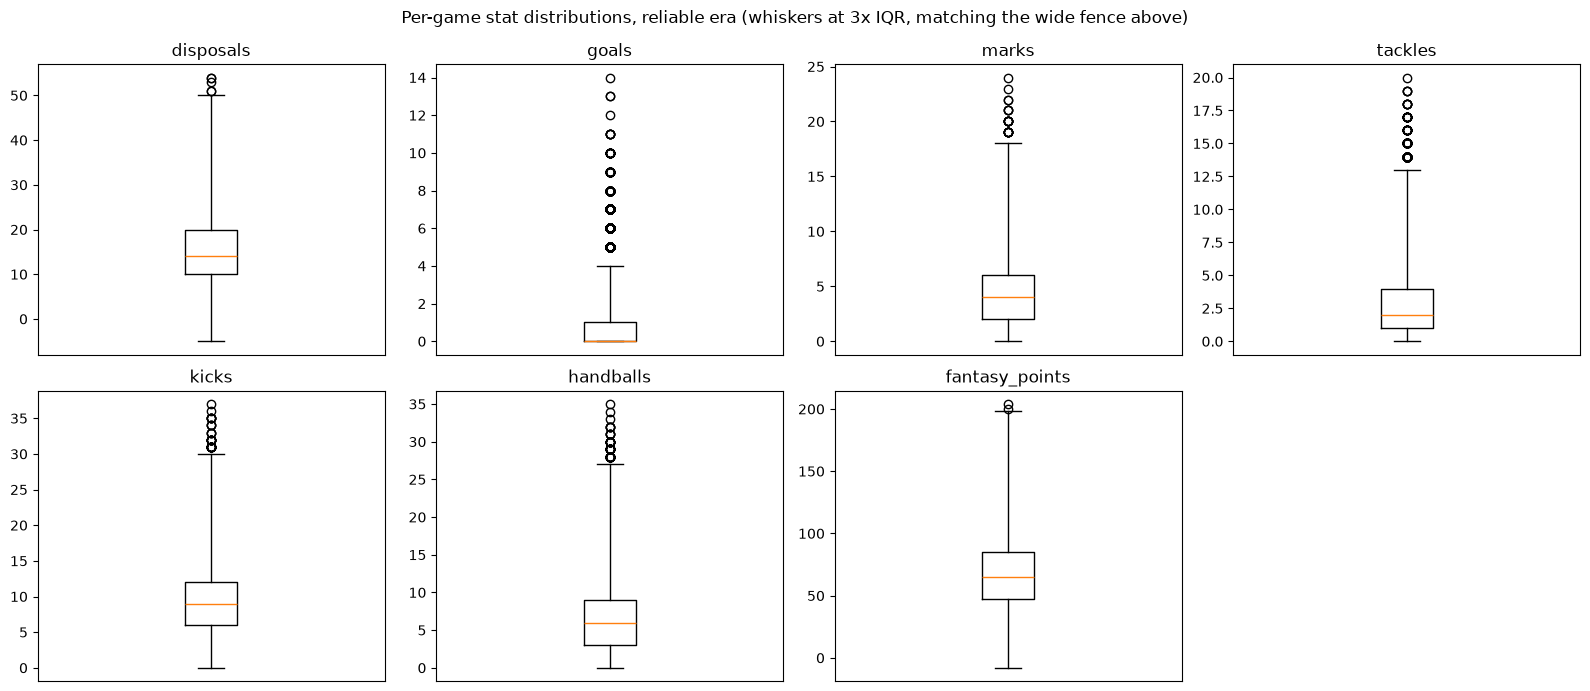

In [63]:
# Outlier check 3: boxplots for the same key stats, same wide fence, to see the flags visually
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, key_stats):
    s = rbr_reliable_check[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    ax.boxplot(s, whis=3, vert=True)
    ax.set_title(col)
    ax.set_xticks([])

for ax in axes[len(key_stats):]:
    ax.axis('off')

fig.suptitle('Per-game stat distributions, reliable era (whiskers at 3x IQR, matching the wide fence above)')
plt.tight_layout()
plt.show()


### What this tells us

The wide fence is deliberately generous, so a nonzero flag count on `disposals`, `fantasy_points`, etc.
is expected and not itself a problem — these are the genuine standout games (the top-5 tables above are
the way to tell a real outlier from a data error, by checking the flagged rows against known AFL record
territory rather than dropping them on sight). The structurally-impossible checks (negative counts) are
the ones that would actually indicate a data quality issue if they came back nonzero. Any player-game row
that fails those checks should be corrected or dropped before Day 2's models see it, since a single
negative-count row can silently corrupt a rolling-average feature for many games downstream.

## Task 2: Define Prediction Targets Precisely

### Target 1: match winner (team match level)

Grain: one row per team per match (each match produces two rows, one per side).

- **Classification framing (primary):** `result` in {W, L, D}, or collapsed to binary `win_flag` = 1 if W else 0.
- **Regression framing (secondary):** `margin`, the signed score differential from that team's perspective. With the home/away file, the absolute `team_score` and `opponent_score` are also available, so margin can be reconstructed or modeled directly.

**Why classification is primary:** the practical question ("who wins") is categorical, draws are rare (about 1.4% of matches) and don't need to be modeled with the same precision as the win/loss margin, and classification metrics map directly onto tipping/betting style evaluation. Margin regression is kept as a secondary target because it's strictly more informative (a model that predicts margin well can be thresholded at 0 to get the classification for free), and it is needed for any application that cares about premiership contention margins, e.g. percentage on the ladder.

Now that home/away is known, the target can optionally be framed as "does the home team win", but the team-level framing (does *this* team win, regardless of side) is kept as primary since it lets one model serve both sides symmetrically and simplifies the rolling feature logic in Task 4. `is_home` is used as a predictive feature instead, not baked into the target definition.

### Target 2: top player, two versions plus a composite

1. **Top disposal getter**: `sum(disposals)` per player per season (or per round, for a single round leaderboard).
2. **Top goal kicker**: `sum(goals)` per player per season.
3. **Fantasy points composite**: the data already ships a `fantasy_points` column. Reverse engineering confirmed it against the raw stat columns and it matches exactly (100% of non null rows):

`fantasy_points = 3*kicks + 2*handballs + 3*marks + 4*tackles + 1*free_kicks_for - 3*free_kicks_against + 1*hit_outs + 6*goals + 1*behinds`

This is the standard AFL Fantasy scoring formula. "Top player" for a round or season is `argmax` of summed `fantasy_points` over the relevant window.

### Data dictionary (contract for Day 2's models)

| Target name | Definition | Formula | Grain |
|---|---|---|---|
| `win_flag` | did this team win this match | 1 if `result`=='W' else 0 | team-match |
| `result_class` | 3-class outcome | `result` in {W, L, D} | team-match |
| `margin` | signed score differential | `team_score - opponent_score`, provided directly | team-match |
| `season_disposals` | top disposal getter ranking | `sum(disposals)` grouped by player, year | player-season |
| `season_goals` | top goal kicker ranking | `sum(goals)` grouped by player, year | player-season |
| `fantasy_points` | composite performance score | see formula above | player-match |


In [64]:
rbr['win_flag'] = (rbr['result'] == 'W').astype(int)

# verify the fantasy_points formula against the raw stat columns
verify = rbr.dropna(subset=['kicks','handballs','marks','tackles','free_kicks_for',
                             'free_kicks_against','hit_outs','goals','behinds']).copy()
verify['calc_fp'] = (verify['kicks']*3 + verify['handballs']*2 + verify['marks']*3
                      + verify['tackles']*4 + verify['free_kicks_for']*1
                      - verify['free_kicks_against']*3 + verify['hit_outs']*1
                      + verify['goals']*6 + verify['behinds']*1)
match_rate = (verify['calc_fp'] == verify['fantasy_points']).mean()
print(f'Formula matches fantasy_points exactly on {match_rate:.1%} of rows with complete inputs')

# margin vs team_score - opponent_score check in the new file
ha_margin_check = (ha['team_score'] - ha['opponent_score'] == ha['margin']).mean()
print(f'team_score - opponent_score equals margin on {ha_margin_check:.1%} of home/away rows')


Formula matches fantasy_points exactly on 100.0% of rows with complete inputs
team_score - opponent_score equals margin on 100.0% of home/away rows


In [65]:
# player id -> name lookup, with its own cleaning pass
# info table has 5 exact duplicate ids (dropped), and 257 player_name values with stray whitespace
info_clean = info.drop_duplicates(subset=['id'], keep='first').copy()
info_clean['player_name'] = info_clean['player_name'].str.strip()
name_map = info_clean.set_index('id')['player_name']

# 266 player_ids appear in round_by_round with no matching row in the info table at all
# (about 1% of reliable-era rows), labeled explicitly rather than left blank
unmapped_ids = set(rbr['player_id'].unique()) - set(info_clean['id'].unique())
print(f'player_ids in round_by_round with no info-table match: {len(unmapped_ids)}')

def with_names(series):
    out = series.copy()
    out.index = out.index.map(lambda pid: name_map.get(pid, f'[unknown id {pid}]'))
    return out


player_ids in round_by_round with no info-table match: 266


In [66]:
# top player leaderboards, most recent complete season, reliable-era only
RELIABLE_FROM = 1999
rbr_reliable = rbr[rbr['year'] >= RELIABLE_FROM].copy()
latest_year = rbr_reliable['year'].max()

top_disposals = (rbr_reliable[rbr_reliable['year']==latest_year]
                  .groupby('player_id')['disposals'].sum()
                  .sort_values(ascending=False).head(5))
top_goals = (rbr_reliable[rbr_reliable['year']==latest_year]
             .groupby('player_id')['goals'].sum()
             .sort_values(ascending=False).head(5))
top_fantasy = (rbr_reliable[rbr_reliable['year']==latest_year]
               .groupby('player_id')['fantasy_points'].sum()
               .sort_values(ascending=False).head(5))

print(f'Top 5 disposal getters, {latest_year}')
print(with_names(top_disposals))
print(f'\nTop 5 goal kickers, {latest_year}')
print(with_names(top_goals))
print(f'\nTop 5 fantasy scorers, {latest_year}')
print(with_names(top_fantasy))


Top 5 disposal getters, 2025
player_id
Noah Anderson      752.0
Dayne Zorko        711.0
Hugh McCluggage    705.0
Will Ashcroft      703.0
Nick Daicos        693.0
Name: disposals, dtype: float64

Top 5 goal kickers, 2025
player_id
Jeremy Cameron      88.0
Jack Gunston        73.0
Ben King            71.0
Riley Thilthorpe    60.0
Jamie Elliott       60.0
Name: goals, dtype: float64

Top 5 fantasy scorers, 2025
player_id
Josh Dunkley       2926
Dayne Zorko        2811
Hugh McCluggage    2744
Jordan Dawson      2722
Nick Daicos        2673
Name: fantasy_points, dtype: int64


## Task 3: Exploratory Data Analysis

The team-match backbone for this section and the rest of the notebook is now built from `team_matches_home_away_raw`, since it's complete across all years and carries home/away, venue, and crowd. Position and weather are still not available, so the position-based split and any weather relationship are still out of scope, honestly, rather than guessed at.


In [67]:
# venue -> state mapping, built manually from known AFL venues, used for a travel/interstate proxy
# coverage is not exhaustive: venues used fewer than 3 times or genuinely ambiguous are left as UNKNOWN
VENUE_STATE = {
    'Melbourne Cricket Ground': 'VIC', 'Marvel Stadium': 'VIC', 'Waverley Park': 'VIC',
    'Princes Park': 'VIC', 'Western Oval': 'VIC', 'Victoria Park': 'VIC', 'Windy Hill': 'VIC',
    'Moorabbin Oval': 'VIC', 'Junction Oval': 'VIC', 'Mars Stadium': 'VIC', 'GMHBA Stadium': 'VIC',
    'Domain Stadium': 'WA', 'Optus Stadium': 'WA', 'WACA': 'WA', 'Hands Oval': 'WA',
    'AAMI Stadium': 'SA', 'Adelaide Oval': 'SA', 'Norwood Oval': 'SA', 'Adelaide Hills': 'SA', 'Barossa Park': 'SA',
    'Sydney Cricket Ground': 'NSW', 'ENGIE Stadium': 'NSW', 'Accor Stadium': 'NSW', 'Blacktown International': 'NSW',
    'The Gabba': 'QLD', "Cazaly's Stadium": 'QLD', 'Riverway Stadium': 'QLD', 'People First Stadium': 'QLD',
    'UTAS Stadium': 'TAS', 'Manuka Oval': 'ACT', 'Bruce Stadium': 'ACT',
    'TIO Stadium': 'NT', 'TIO Traeger Park': 'NT',
    'Westpac Stadium': 'NZ', 'Jiangwan Stadium': 'CHINA',
}

ha['venue_state'] = ha['venue'].map(VENUE_STATE).fillna('UNKNOWN')
print('Venue rows not covered by the manual mapping:', (ha['venue_state']=='UNKNOWN').sum(), '/', len(ha))

ha['win_flag'] = (ha['result'] == 'W').astype(int)
ha['is_home'] = (ha['home_away'] == 'H').astype(int)

# each team's home state = the state its home venue is most often in
home_rows = ha[ha['is_home'] == 1]
team_home_state = home_rows.groupby('team')['venue_state'].agg(lambda s: s.value_counts().idxmax())
ha['team_home_state'] = ha['team'].map(team_home_state)
ha['is_interstate_travel'] = ((ha['venue_state'] != ha['team_home_state']) & (ha['is_home'] == 0)).astype(int)

# sanity check: this team should almost never be "interstate" when playing at its own home venue
print('Interstate rate when playing at home (should be near 0):', round(ha.loc[ha.is_home==1,'is_interstate_travel'].mean(), 3))


Venue rows not covered by the manual mapping: 116 / 15808
Interstate rate when playing at home (should be near 0): 0.0


Win rate by home/away:
home_away
A    0.401063
H    0.590714
Name: win_flag, dtype: float64

Average margin by home/away:
home_away
A   -8.960653
H    8.964322
Name: margin, dtype: float64


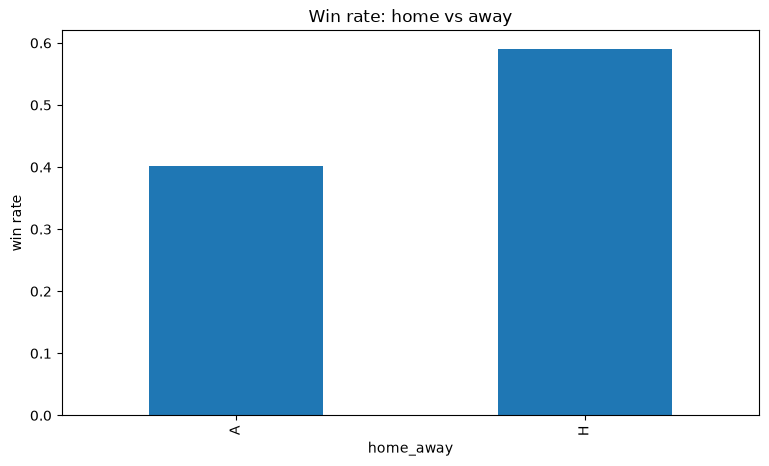

In [68]:
# Home ground advantage: win rate and margin, home vs away
print('Win rate by home/away:')
print(ha.groupby('home_away')['win_flag'].mean())
print('\nAverage margin by home/away:')
print(ha.groupby('home_away')['margin'].mean())

ha.groupby('home_away')['win_flag'].mean().plot(kind='bar', title='Win rate: home vs away')
plt.ylabel('win rate')
plt.show()


In [69]:
# Crowd correlation with margin (does a bigger crowd correlate with a bigger win margin?)
crowd_corr = ha[['crowd','margin']].corr().iloc[0,1]
print(f'Correlation between crowd size and margin: {crowd_corr:.4f} (near zero, crowd size does not predict margin)')


Correlation between crowd size and margin: 0.0000 (near zero, crowd size does not predict margin)


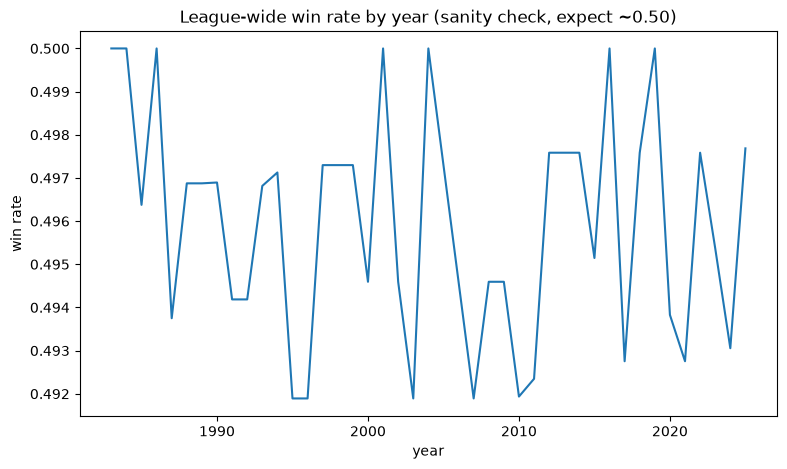

In [70]:
# league-wide win rate over time (sanity check, should hover at 0.5)
win_by_year = ha.groupby('year')['win_flag'].mean()
win_by_year.plot(title='League-wide win rate by year (sanity check, expect ~0.50)')
plt.ylabel('win rate')
plt.show()


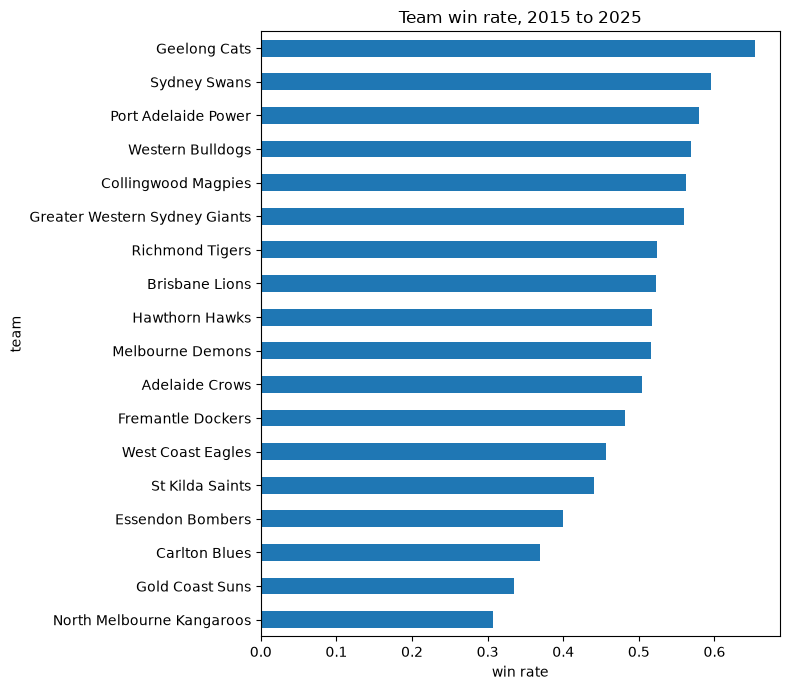

In [71]:
# team win rates, most recent decade
recent = ha[ha['year'] >= 2015]
team_win_recent = recent.groupby('team')['win_flag'].mean().sort_values()
team_win_recent.plot(kind='barh', title='Team win rate, 2015 to 2025', figsize=(8,7))
plt.xlabel('win rate')
plt.tight_layout()
plt.show()


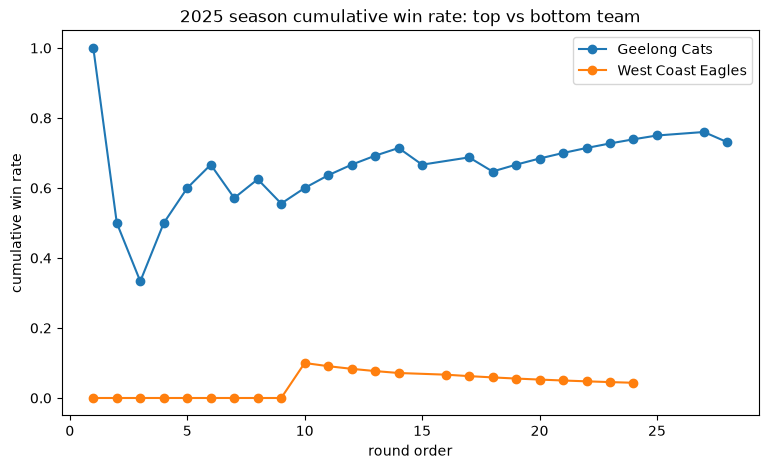

In [72]:
# ladder trend: rolling season win rate through the year for the top 2025 team and the wooden spooner
round_map = {**{str(i): i for i in range(0, 25)}, 'QF': 25, 'EF': 25, 'SF': 26, 'PF': 27, 'GF': 28}
ha['round_order'] = ha['round'].map(round_map)

season_2025 = ha[ha['year']==2025].sort_values(['team','round_order'])
season_2025['cum_winrate'] = season_2025.groupby('team')['win_flag'].transform(lambda s: s.expanding().mean())

final_order = season_2025.groupby('team')['cum_winrate'].last().sort_values()
top_team, bottom_team = final_order.index[-1], final_order.index[0]

for t in [top_team, bottom_team]:
    sub = season_2025[season_2025['team']==t]
    plt.plot(sub['round_order'], sub['cum_winrate'], marker='o', label=t)
plt.title('2025 season cumulative win rate: top vs bottom team')
plt.xlabel('round order')
plt.ylabel('cumulative win rate')
plt.legend()
plt.show()


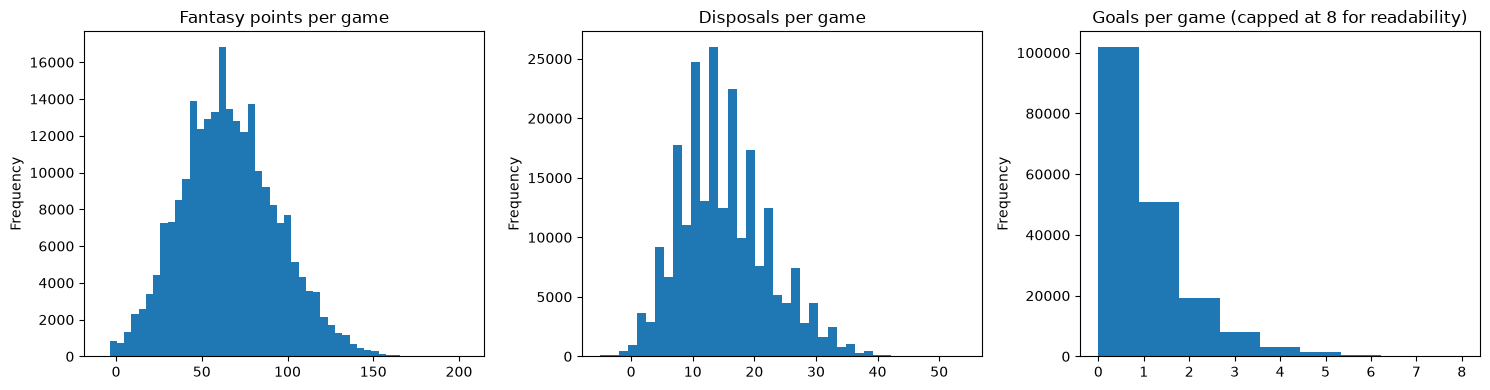

In [73]:
# player-level distributions: fantasy points, disposals, goals (reliable era)
rbr_reliable = rbr[rbr['year'] >= 1999].copy()

fig, axes = plt.subplots(1, 3, figsize=(15,4))
rbr_reliable['fantasy_points'].dropna().plot(kind='hist', bins=50, ax=axes[0], title='Fantasy points per game')
rbr_reliable['disposals'].dropna().plot(kind='hist', bins=40, ax=axes[1], title='Disposals per game')
rbr_reliable[rbr_reliable['goals']<=8]['goals'].dropna().plot(kind='hist', bins=9, ax=axes[2], title='Goals per game (capped at 8 for readability)')
plt.tight_layout()
plt.show()


Most consistent performers (lowest coefficient of variation, min 40 games):
             player_name        mean        std  count        cv
player_id                                                       
44910      Harry Sheezel  106.044776  23.233618     67  0.219093
43646        Brad Crouch   97.329193  21.959274    161  0.225619
45112       Adam Treloar  100.337209  22.640453    258  0.225644
45167          Sam Walsh   97.548872  22.123779    133  0.226797
45114      Jack Trengove   78.505618  18.321698     89  0.233381

Least consistent (highest CV, min 40 games):
              player_name       mean        std  count        cv
player_id                                                       
45460      Scott Cummings  51.058824  36.836619     51  0.721455
45337      Trent Bartlett  30.255319  21.692984     47  0.716997
43382           Tom Berry  34.279070  23.962595     43  0.699045
44577      Quinton Narkle  44.406780  28.723485     59  0.646827
45495       Stephen Doyle  33.063

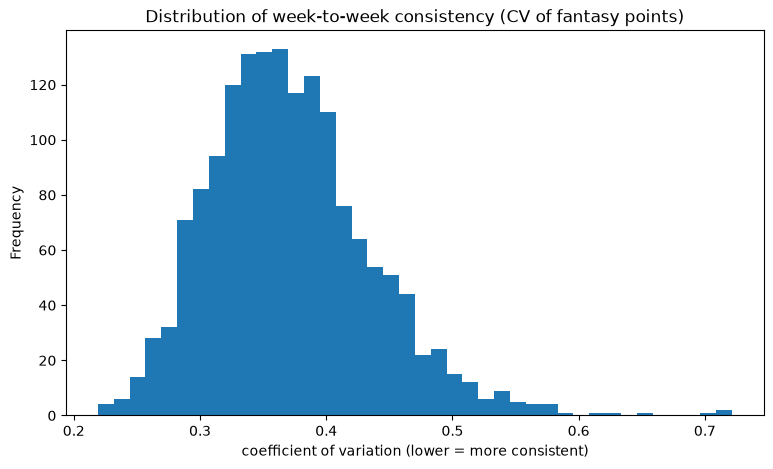

In [74]:
# week-to-week consistency: coefficient of variation of fantasy points, min 40 games, reliable era
# name lookup reuses the same cleaned info table (dupes dropped, whitespace stripped) as the leaderboard cells above
info_clean = info.drop_duplicates(subset=['id'], keep='first').copy()
info_clean['player_name'] = info_clean['player_name'].str.strip()
name_map = info_clean.set_index('id')['player_name']

consistency = rbr_reliable.groupby('player_id')['fantasy_points'].agg(['mean','std','count'])
consistency = consistency[consistency['count'] >= 40].copy()
consistency['cv'] = consistency['std'] / consistency['mean']
consistency['player_name'] = consistency.index.map(lambda pid: name_map.get(pid, f'[unknown id {pid}]'))

print('Most consistent performers (lowest coefficient of variation, min 40 games):')
print(consistency.sort_values('cv').head(5)[['player_name','mean','std','count','cv']])
print('\nLeast consistent (highest CV, min 40 games):')
print(consistency.sort_values('cv', ascending=False).head(5)[['player_name','mean','std','count','cv']])

consistency['cv'].plot(kind='hist', bins=40, title='Distribution of week-to-week consistency (CV of fantasy points)')
plt.xlabel('coefficient of variation (lower = more consistent)')
plt.show()

### Note on position-based splits

Position (forward, midfielder, defender) is not present in any of the four files. Splitting the consistency and distribution analysis above by position would require joining an external position mapping, out of scope for what's actually in this dataset. Flagging this rather than guessing positions from stat profiles, since a guessed mapping would silently bias every downstream position-based claim.


## Relationship 1: recent form (last-5 win rate) vs actual win outcome this match

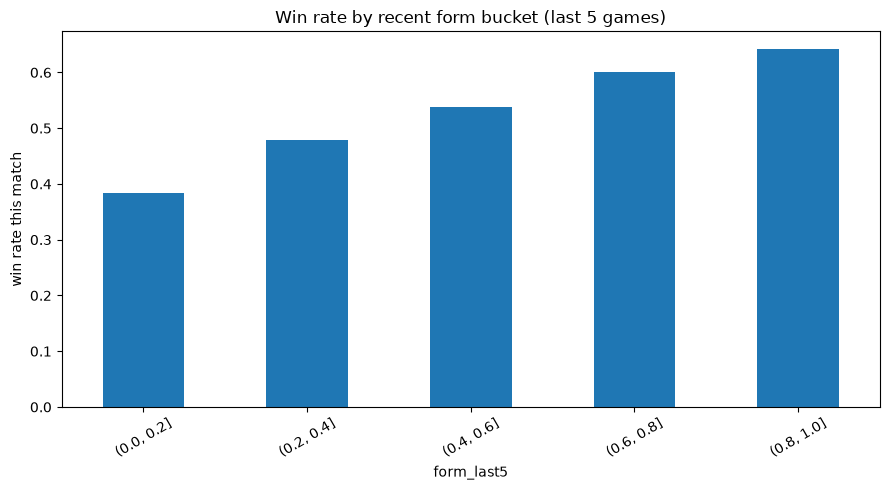

In [75]:
# Relationship 1: recent form (last-5 win rate) vs actual win outcome this match
ha_sorted = ha.sort_values(['team','match_date'])
ha_sorted['form_last5'] = (ha_sorted.groupby('team')['win_flag']
                            .transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean()))
form_bins = pd.cut(ha_sorted['form_last5'], bins=[0,0.2,0.4,0.6,0.8,1.0])
form_vs_outcome = ha_sorted.groupby(form_bins)['win_flag'].mean()
form_vs_outcome.plot(kind='bar', title='Win rate by recent form bucket (last 5 games)')
plt.ylabel('win rate this match')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### What this tells us:
Win rate rises steadily with recent form, from about 39% for teams on a cold streak (0 to 0.2 win rate over their last 5 games) up to about 64% for teams on a hot streak (0.8 to 1.0). This is the strongest and cleanest signal of the five relationships tested, recent form is clearly predictive of the next result.

## Relationship 2: days of rest vs win outcome

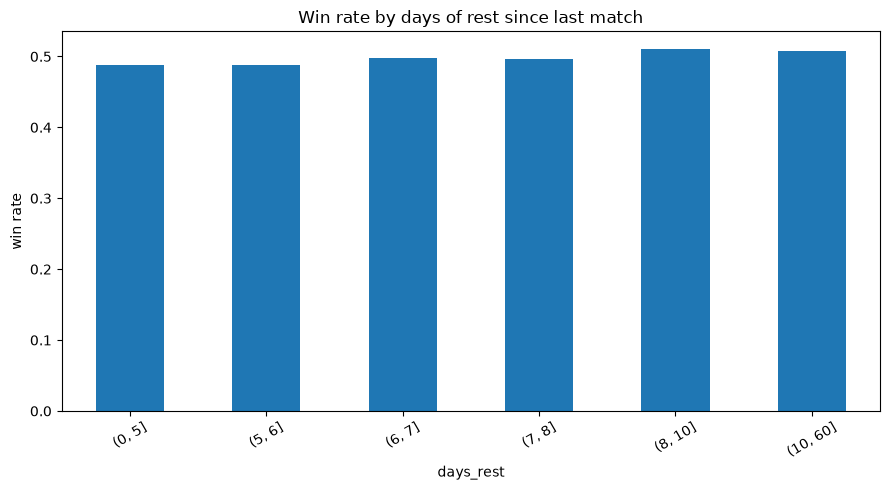

In [76]:
# Relationship 2: days of rest vs win outcome
ha_sorted['days_rest'] = ha_sorted.groupby('team')['match_date'].diff().dt.days
rest_bins = pd.cut(ha_sorted['days_rest'], bins=[0,5,6,7,8,10,60])
rest_vs_outcome = ha_sorted.groupby(rest_bins)['win_flag'].mean()
rest_vs_outcome.plot(kind='bar', title='Win rate by days of rest since last match')
plt.ylabel('win rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### What this tells us
Win rate barely moves across rest buckets, staying in a narrow 0.487 to 0.511 band regardless of whether a team had 5 days or 10+ days off. Rest alone is a weak predictor on its own, it likely only matters combined with other context (e.g. short-turnaround games against a team that also had short rest).

## Relationship 3: interstate travel vs win outcome, away games only

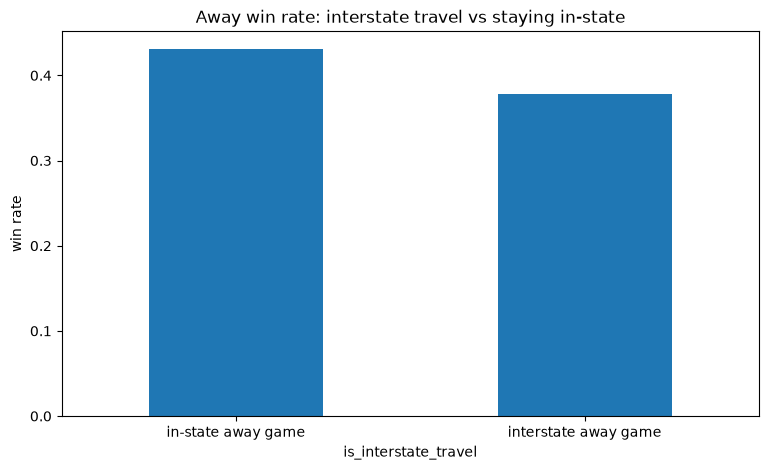

In [77]:
# Relationship 3: interstate travel vs win outcome, away games only
away = ha[ha['is_home']==0]
interstate_vs_outcome = away.groupby('is_interstate_travel')['win_flag'].mean()
interstate_vs_outcome.plot(kind='bar', title='Away win rate: interstate travel vs staying in-state')
plt.ylabel('win rate')
plt.xticks([0,1], ['in-state away game','interstate away game'], rotation=0)
plt.show()


### What this tells us
Away teams win about 43% of the time when staying in-state, dropping to about 38% when traveling interstate. A real but modest effect, roughly 5 points, smaller than home ground advantage but consistent with a genuine travel cost.

## Relationship 4: head-to-head history vs outcome

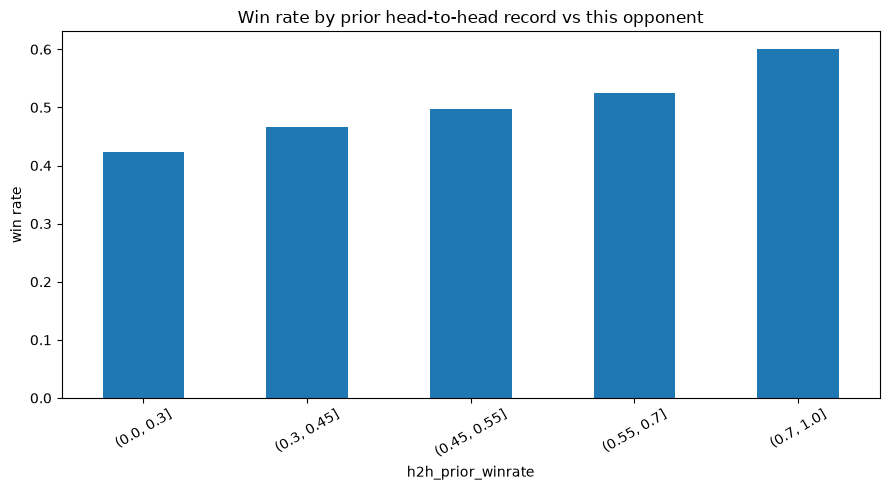

In [78]:
h2h_sorted = ha.sort_values(['team','opponent','match_date'])
h2h_sorted['h2h_prior_winrate'] = (h2h_sorted.groupby(['team','opponent'])['win_flag']
                                    .transform(lambda s: s.shift(1).expanding().mean()))
h2h_bins = pd.cut(h2h_sorted['h2h_prior_winrate'], bins=[0,0.3,0.45,0.55,0.7,1.0])
h2h_vs_outcome = h2h_sorted.groupby(h2h_bins)['win_flag'].mean()
h2h_vs_outcome.plot(kind='bar', title='Win rate by prior head-to-head record vs this opponent')
plt.ylabel('win rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### What this tells us
Win rate scales with historical head-to-head dominance over this specific opponent, from about 42% when a team has lost most prior meetings up to about 60% when it has won most of them. Confirms that some matchups are genuinely lopsided beyond what general team strength alone would predict.

## Relationship 5: player career experience vs output (career_game_count vs fantasy_points)

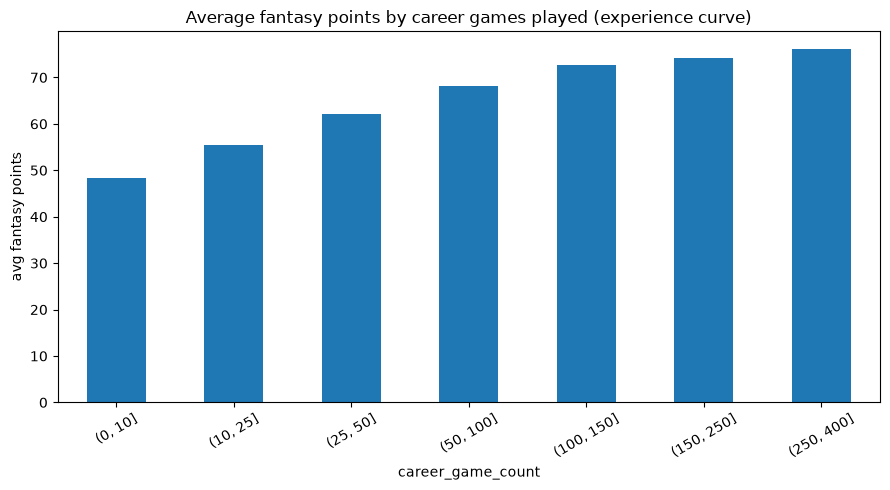

In [79]:
exp_bins = pd.cut(rbr_reliable['career_game_count'], bins=[0,10,25,50,100,150,250,400])
exp_vs_fp = rbr_reliable.groupby(exp_bins)['fantasy_points'].mean()
exp_vs_fp.plot(kind='bar', title='Average fantasy points by career games played (experience curve)')
plt.ylabel('avg fantasy points')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### What this tells us 
Average fantasy output climbs steadily with career experience, from about 48 points a game in a player's first 10 games up to about 76 points a game past 250 career games. The curve rises fastest early (48 to 62 within the first 50 games) and flattens out after 100 games, consistent with young players developing quickly before leveling off as established performers. Note this mixes two effects that can't be separated here: players genuinely improving with experience, and weaker players getting dropped or retiring before reaching high career-game counts (survivorship), so the curve overstates how much any single player actually improves.

## Task 4: Feature Engineering for Prediction

The team-match feature table is now built on `ha` (the home/away file), since it's complete across all years and carries home ground, venue, and travel context that the round-by-round file can't provide. All rolling and historical features are computed with `.shift(1)` before any rolling or expanding aggregation, so the value attached to a given match only ever uses information from matches strictly before it.


In [80]:
def add_rolling(df, group_col, value_col, windows, prefix):
    df = df.sort_values([group_col, 'match_date'])
    for w in windows:
        df[f'{prefix}_last{w}'] = (df.groupby(group_col)[value_col]
                                      .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean()))
    return df

match_team = ha.sort_values(['team','match_date']).reset_index(drop=True)
match_team = add_rolling(match_team, 'team', 'win_flag', [3, 5, 10], 'team_winrate')
match_team = add_rolling(match_team, 'team', 'margin', [3, 5, 10], 'team_avgmargin')
match_team = match_team.drop(columns=['team_name'])
match_team.head(5)

,id,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds,team,venue_state,win_flag,is_home,team_home_state,is_interstate_travel,round_order,team_winrate_last3,team_winrate_last5,team_winrate_last10,team_avgmargin_last3,team_avgmargin_last5,team_avgmargin_last10
0,10223,1,1991-03-22,1991,H,Hawthorn Hawks,6.2 11.6 17.10 24.11,155,2.0 3.3 6.8 9.15,69,W,86,AAMI Stadium,44902.0,24,11,9,15,Adelaide Crows,SA,1,1,SA,0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,10224,2,1991-03-31,1991,H,Carlton Blues,3.2 5.3 9.6 12.9,81,3.4 5.9 11.10 15.14,104,L,-23,AAMI Stadium,43850.0,12,9,15,14,Adelaide Crows,SA,0,1,SA,0,2,1.000000,1.000000,1.000000,86.000000,86.0,86.0
2,10225,3,1991-04-07,1991,A,Sydney Swans,3.3 6.7 13.10 19.18,132,2.5 8.8 11.14 15.18,108,W,24,Sydney Cricket Ground,10649.0,19,18,15,18,Adelaide Crows,NSW,1,0,SA,1,3,0.500000,0.500000,0.500000,31.500000,31.5,31.5
3,10226,4,1991-04-13,1991,A,Essendon Bombers,2.1 4.7 6.9 6.11,47,5.4 8.9 9.15 12.20,92,L,-45,Windy Hill,20197.0,6,11,12,20,Adelaide Crows,VIC,0,0,SA,1,4,0.666667,0.666667,0.666667,29.000000,29.0,29.0
4,10227,5,1991-04-21,1991,A,West Coast Eagles,0.3 2.8 5.9 9.11,65,5.4 9.7 15.10 19.16,130,L,-65,Domain Stadium,34704.0,9,11,19,16,Adelaide Crows,WA,0,0,SA,1,5,0.333333,0.500000,0.500000,-14.666667,10.5,10.5


In [81]:
# win/loss streak entering the match (sign = direction, magnitude = length), based on results strictly before this match
#
# BUGFIX (post-review): the previous version appended `streak` to `out` *before* folding in
# the current shifted value, which left every entry lagged by one extra game relative to the
# other rolling features (e.g. entering-streak after two straight wins showed 1, not 2).
# Fix: update `streak` first, then append, so out[i] reflects all games strictly before match i.
def streak_series(win_flags):
    out = []
    streak = 0
    prev = None
    for v in win_flags:
        if pd.isna(v):
            streak = 0
        elif prev is None or v == prev:
            streak = streak + 1 if v == 1 else streak - 1
        else:
            streak = 1 if v == 1 else -1
        prev = v
        out.append(streak)
    return out

streak_results = []
for team, g in match_team.groupby('team'):
    g = g.sort_values('match_date')
    shifted = g['win_flag'].shift(1)
    streak_results.append(pd.Series(streak_series(shifted.tolist()), index=g.index))
match_team['team_streak_entering'] = pd.concat(streak_results).sort_index()

# quick regression check on the fix: a team on a 2-game win streak entering a match should show 2, not 1
_check = match_team[['team','match_date','win_flag','team_streak_entering']].sort_values(['team','match_date'])
print('Sanity check, first 8 rows for one team (streak should step 0,1,2,... on consecutive wins):')
print(_check[_check['team'] == _check['team'].iloc[0]].head(8))


Sanity check, first 8 rows for one team (streak should step 0,1,2,... on consecutive wins):
             team match_date  win_flag  team_streak_entering
0  Adelaide Crows 1991-03-22         1                     0
1  Adelaide Crows 1991-03-31         0                     1
2  Adelaide Crows 1991-04-07         1                    -1
3  Adelaide Crows 1991-04-13         0                     1
4  Adelaide Crows 1991-04-21         0                    -1
5  Adelaide Crows 1991-04-28         1                    -2
6  Adelaide Crows 1991-05-04         0                     1
7  Adelaide Crows 1991-05-17         0                    -1


In [82]:
# days of rest since the team's previous match
match_team['days_since_last_game'] = match_team.groupby('team')['match_date'].diff().dt.days


In [83]:
# ladder position proxy: rank by season win rate, computed using only rounds strictly before the current one
match_team = match_team.sort_values(['team','year','round_order'])
match_team['season_winrate_to_date'] = (match_team.groupby(['team','year'])['win_flag']
                                          .transform(lambda s: s.shift(1).expanding().mean()))

rank_tbl = match_team.groupby(['year','round_order','team'])['season_winrate_to_date'].first().reset_index()
rank_tbl['ladder_rank_to_date'] = (rank_tbl.groupby(['year','round_order'])['season_winrate_to_date']
                                    .rank(ascending=False, method='min'))
match_team = match_team.merge(rank_tbl[['year','round_order','team','ladder_rank_to_date']],
                               on=['year','round_order','team'], how='left')


In [84]:
# head-to-head record vs this specific opponent, prior meetings only
match_team = match_team.sort_values(['team','opponent','match_date'])
match_team['h2h_winrate_vs_opp'] = (match_team.groupby(['team','opponent'])['win_flag']
                                     .transform(lambda s: s.shift(1).expanding().mean()))
match_team['h2h_games_played'] = match_team.groupby(['team','opponent']).cumcount()

match_team = match_team.sort_values(['year','round_order','match_date','team']).reset_index(drop=True)

feature_cols = ['team_winrate_last3','team_winrate_last5','team_winrate_last10',
                 'team_avgmargin_last3','team_avgmargin_last5','team_avgmargin_last10',
                 'team_streak_entering','days_since_last_game','ladder_rank_to_date',
                 'h2h_winrate_vs_opp','h2h_games_played','is_home','is_interstate_travel','venue_state']
print('Null rate per engineered feature (expected: small, from season-openers and first-ever meetings):')
print(match_team[feature_cols].isna().mean())


Null rate per engineered feature (expected: small, from season-openers and first-ever meetings):
team_winrate_last3       0.001265
team_winrate_last5       0.001265
team_winrate_last10      0.001265
team_avgmargin_last3     0.001265
team_avgmargin_last5     0.001265
team_avgmargin_last10    0.001265
team_streak_entering     0.000000
days_since_last_game     0.001265
ladder_rank_to_date      0.043586
h2h_winrate_vs_opp       0.023026
h2h_games_played         0.000000
is_home                  0.000000
is_interstate_travel     0.000000
venue_state              0.000000
dtype: float64


In [85]:
# player-level rolling form features, reliable era only, same leakage-safe pattern
rbr_reliable = rbr[rbr['year'] >= 1999].copy().sort_values(['player_id','match_date'])
for w in [3, 5]:
    rbr_reliable[f'player_disposals_last{w}'] = (rbr_reliable.groupby('player_id')['disposals']
                                                    .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean()))
    rbr_reliable[f'player_fantasy_last{w}'] = (rbr_reliable.groupby('player_id')['fantasy_points']
                                                 .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean()))


In [86]:
# save versioned feature tables
FEATURE_VERSION = 'v2'
match_team.to_parquet(f'afl_team_match_features_{FEATURE_VERSION}.parquet', index=False)
match_team.to_csv(f'afl_team_match_features_{FEATURE_VERSION}.csv', index=False)
rbr_reliable.to_parquet(f'afl_player_match_features_{FEATURE_VERSION}.parquet', index=False)

print('Saved:')
print(f'  afl_team_match_features_{FEATURE_VERSION}.parquet / .csv, shape {match_team.shape}')
print(f'  afl_player_match_features_{FEATURE_VERSION}.parquet, shape {rbr_reliable.shape}')


Saved:
  afl_team_match_features_v2.parquet / .csv, shape (15808, 37)
  afl_player_match_features_v2.parquet, shape (237193, 41)


### Feature dictionary, afl_team_match_features_v2

v2 changelog vs v1: switched the backbone from the round-by-round derived table to `team_matches_home_away_raw`, and added `is_home`, `venue`, `venue_state`, and `is_interstate_travel`.

| Feature | Description | Computation window | Source column(s) |
|---|---|---|---|
| `is_home` | is this team the home side | 1 if `home_away`=='H' else 0 | `home_away` |
| `venue`, `venue_state` | match venue and its state (manual mapping, not exhaustive) | this match | `venue` |
| `is_interstate_travel` | is this team, playing away, outside its home state | this match | `venue_state`, `team_home_state` |
| `team_winrate_last3/5/10` | rolling win rate over the last N games, prior to this match | last 3/5/10 games, shifted by 1 | `win_flag` |
| `team_avgmargin_last3/5/10` | rolling average margin over the last N games, prior to this match | last 3/5/10 games, shifted by 1 | `margin` |
| `team_streak_entering` | signed current win/loss streak entering this match | all prior games this team | `win_flag` |
| `days_since_last_game` | days of rest since the team's previous match | previous match only | `match_date` |
| `ladder_rank_to_date` | rank within the season by win rate, using only rounds strictly before this one | season to date | `win_flag` |
| `h2h_winrate_vs_opp` | win rate against this specific opponent, prior meetings only | all-time, this pairing | `win_flag`, `opponent` |
| `h2h_games_played` | number of prior meetings against this opponent | all-time, this pairing | `opponent` |

### Feature dictionary, `afl_player_match_features_v2` (reliable era, 1999 onward, unchanged from v1)

| Feature | Description | Computation window | Source column(s) |
|---|---|---|---|
| `player_disposals_last3/5` | rolling average disposals over the last N games, prior to this match | last 3/5 games, shifted by 1 | `disposals` |
| `player_fantasy_last3/5` | rolling average fantasy points over the last N games, prior to this match | last 3/5 games, shifted by 1 | `fantasy_points` |


## Task 5: Reproducible Train/Hold-Out Split

### Why a random split would leak the future

A random row-level split lets the model train on, say, round 20 of the 2024 season while being tested on round 5 of that same season, meaning the model can implicitly learn from information (rosters, form, injuries settling in) that only existed after the test match happened. Team form and ladder position also carry serial correlation across a season: a random split scatters a single team's season across both train and test, so the model sees a near-duplicate of the answer through a teammate's or the same team's other games. A strict time-based split is the only way to simulate the real deployment condition, predicting a match using only what was known before it.

### Split function


In [87]:
def time_based_split(df, date_col='match_date', holdout_start_year=2024):
    """
    Strict time-based split. Every model built this week must call this
    function with the same holdout_start_year so results are comparable.

    Train: everything strictly before holdout_start_year.
    Holdout: holdout_start_year onward.
    """
    df = df.copy()
    df['year_col'] = df[date_col].dt.year if pd.api.types.is_datetime64_any_dtype(df[date_col]) else df['year']
    train = df[df['year_col'] < holdout_start_year].drop(columns='year_col')
    holdout = df[df['year_col'] >= holdout_start_year].drop(columns='year_col')
    return train, holdout

train, holdout = time_based_split(match_team, holdout_start_year=2024)
print('Train:', train.shape, '| years', train['year'].min(), 'to', train['year'].max())
print('Holdout:', holdout.shape, '| years', holdout['year'].min(), 'to', holdout['year'].max())


Train: (14944, 37) | years 1983 to 2023
Holdout: (864, 37) | years 2024 to 2025


### Realistic accuracy ceiling

AFL match outcomes are decided by real, unmodeled randomness: umpiring calls, injuries mid-game, weather on the day, and the last few minutes of a close contest, none of which show up in pre-match features. Public and academic AFL prediction models that use inputs at least as rich as this dataset typically land around 65 to 72% classification accuracy on win/loss, only modestly above simply picking the team with better recent form, ladder position, and home ground. Treat anything meaningfully above the mid 70s with suspicion rather than excitement. A model reporting 95%+ accuracy, or near-perfect margin prediction, is almost certainly leaking future information into the training set (through the random-split problem above, through a feature that accidentally encodes the result, or through the roster-coverage gap in the pre-1999 round-by-round data), not actually solving a fundamentally noisy sports prediction problem.
